# Introduction to Gradient Descent

This notebook looks at:

* Implementing basic gradient descent.
* The effects of step size on gradient descent.
* The effects of starting position on gradient descent.

In [1]:
# Import libraries

import numpy as np
import matplotlib.pyplot as plt


### Implementing Gradient Descent

We will return to our mystery function at the end of this notebook, but for now let's deal with a different example.

Create a function $\mathcal{L}(\theta)=\sqrt{1-\exp(-\theta^2/10)}$. Plot it on the interval (-4,4).

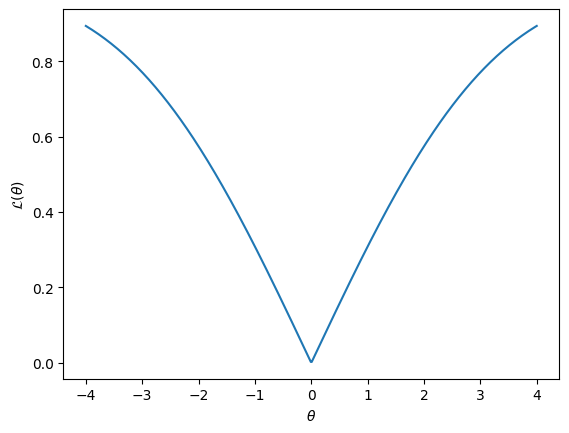

In [2]:
# define the function f and plot on the interval (-4, 4)
L = lambda theta: np.sqrt(1 - np.exp(-(theta ** 2) / 10))
theta = np.linspace(-4, 4, 500)
plt.plot(
    theta, L(theta)
)  # In an ML context as in the slides, L(y(theta)), but we can ignore the intermediate step for simplicity.
plt.xlabel(r"$\theta$")
plt.ylabel(r"$\mathcal{L}(\theta)$")
plt.show()


The gradient of that function is

$$g(\theta) = \nabla \mathcal{L}(\theta) = \theta \frac{\exp(-\theta^2/10)}{10\mathcal{L}(\theta)} $$

(🦉 *Note; $\nabla$ is often used as a shorthand for $\frac{\partial \mathcal{L}}{\partial \theta}$; by writing $\mathcal{L}(\theta)$ we make it clear the derivatives are with respect to $\theta$. For those interested, the derivation of the gradient is provided at the end of this notebook.*)

Create this function $g(\theta)$, the gradient of $\mathcal{L}(\theta)$, and plot it together with the original function. Make sure you understand the relationship between the slope of $\mathcal{L}(\theta)$ and $g(\theta)$.

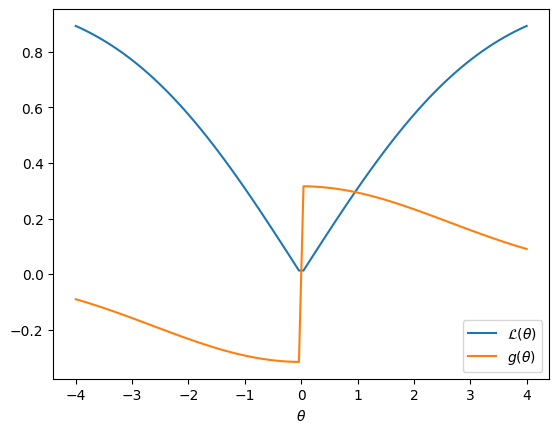

In [3]:
# define the function g and plot on the interval (-4, 4) with f
g = lambda theta: theta * np.exp(-(theta ** 2) / 10) / (10 * L(theta))
theta = np.linspace(-4, 4, 100)
plt.plot(theta, L(theta), label=r"$\mathcal{L}(\theta)$")
plt.plot(theta, g(theta), label=r"$g(\theta)$")
plt.xlabel(r"$\theta$")
plt.legend()
plt.show()


Write a function `simpleGD` with **inputs**:
* a starting point `theta_0`
* a function `L`
* the function L's gradient `g`
* a learning rate `lmbda` (also known as the stepsize)
* and a number of steps, `nr_steps`, to iterate over

and that **returns**: 
* a 2D array of points:
```
    array([[theta_0, L(theta_0)],
           [theta_1, L(theta_1)],
           ....
           [theta_n, L(theta_n)])
```

where each `[theta_t, L(theta_t)]` pair is generated from the previous pair using simple gradient descent:

$$\theta_{t} = \theta_{t-1} - \lambda \frac{\partial \mathcal{L}(f(\theta_{t-1};x))}{\partial \theta}.  $$

In [4]:
# create the function simpleGD:
def simpleGD(theta0, L, g, lmbda, nr_steps):
    points = np.zeros((nr_steps + 1, 2))
    points[0, :] = [theta0, L(theta0)]
    theta = theta0
    for ii in range(nr_steps):
        # this formulation amounts to writing x = x - stepsize*g(x)
        theta -= lmbda * g(theta)
        points[ii + 1, :] = [theta, L(theta)]
    return points



Now run your function for `10` steps with inputs $\mathcal{L}(\theta)$ and $g(\theta)$ starting at `-3` and with $\lambda$ set to `0.9`

In [5]:
# apply 10 steps of gradient descent to L (with grad g) starting at -3 with lambda 0.9
gd_points = simpleGD(-3, L, g, 0.9, 10)


Finally, plot the outputs against the underlying function $\mathcal{L}(\theta)$.

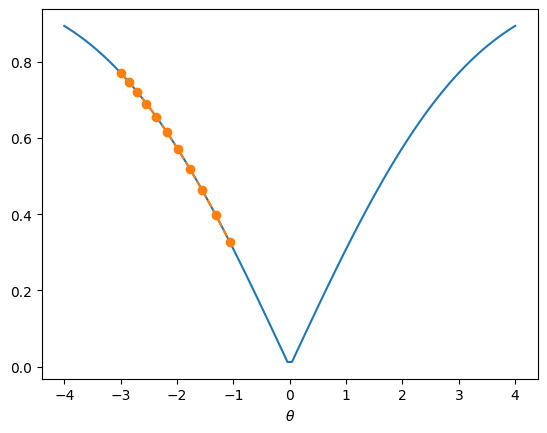

In [6]:
# and plot the output points from simpleGD with the required settings
theta = np.linspace(-4, 4, 100)
plt.plot(theta, L(theta), label="function f")
plt.plot(*gd_points.T, 'o--')
plt.xlabel(r'$\theta$')
plt.show()
# The above is a shortcut for a for loop over all the points
# it unpacks the points. Google 'python starred expression'


### Choice of learning rate

To show the importance of a good step size/learning rate, repeat the above procedure with a function $\mathcal{L}(\theta) = \theta^2$. Take 10 steps of gradient descent starting at `-1` and use `lmbda = 1.05`.

What's the problem here?!

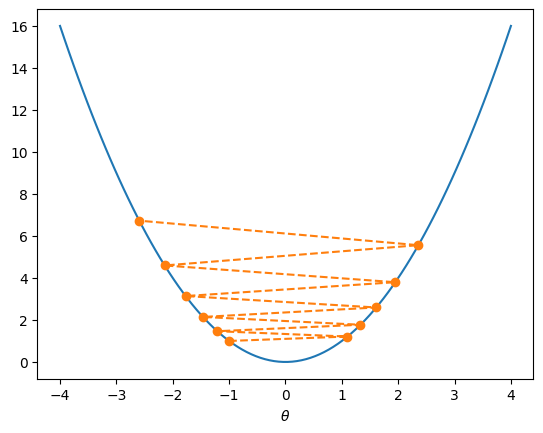

In [7]:
# create a new f and g, apply, and plot the gradient descent
L = lambda theta: theta ** 2
g = lambda theta: 2 * theta
gd_points = simpleGD(-1, L, g, 1.05, 10)
theta = np.linspace(-4, 4, 100)
plt.plot(theta, L(theta), label="function f")
plt.plot(*gd_points.T, "o--")
plt.xlabel(r"$\theta$")
plt.show()


### Choice of starting location

Finally, let's consider the function we were working with in the slides. That function was

$$\mathcal{L}(\theta) = \theta^4 - 4\theta^3 - 2\theta^2 + 5\theta + 31. $$

Its gradient is

$$g(\theta) = 4\theta^3 - 12\theta^2 - 4\theta + 5.$$

Repeat the 10 step procedure above with `theta = 3` and use `lmbda = 0.01`. Plot the results and $\mathcal{L}(\theta)$ in the range `[2.5,4.5]`. 

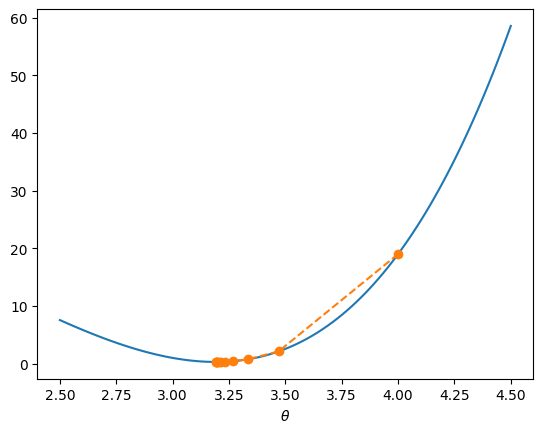

In [8]:
# create a new f and g, apply, and plot the gradient descent
L = lambda theta: theta ** 4 - 4 * theta ** 3 - 2 * theta ** 2 + 5 * theta + 31
g = lambda theta: 4 * theta ** 3 - 12 * theta ** 2 - 4 * theta + 5
gd_points = simpleGD(4, L, g, 0.01, 10)
theta = np.linspace(2.5, 4.5, 100)
plt.plot(theta, L(theta), label="function f")
plt.plot(*gd_points.T, "o--")
plt.xlabel(r"$\theta$")
plt.show()


What do you notice? Compare your results to the gradient descent we ran on the slides, starting at `theta = -1.5`. What is the difference? Plot the function in the range `[-2,5]` to help see what's going on.

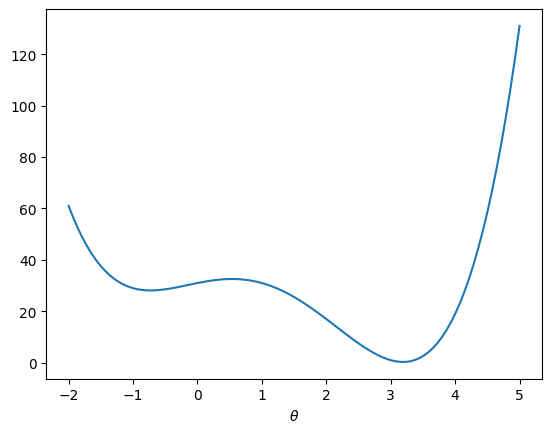

In [9]:
# Plot the function from [-2,5]
theta = np.linspace(-2, 5, 100)
plt.plot(theta, L(theta), label="function f")
plt.xlabel(r'$\theta$')
plt.show()


Feel free to play around with different step sizes/starting locations on this function.

#### Footnote:

Below is the derivation of the gradient for the function $\mathcal{L}(\theta)$, for those interested.

$$
\begin{aligned}
 \nabla \mathcal{L}(\theta) &= \nabla (1 - \exp{\frac{-\theta^2}{10}})^{\frac{1}{2}} \\
 &= \frac{1}{2}(1 - \exp{\frac{-\theta^2}{10}})^{-\frac{1}{2}} \nabla (1 -\exp{\frac{-\theta^2}{10}}) \\
 &= \frac{1}{2}(1 - \exp{\frac{-\theta^2}{10}})^{-\frac{1}{2}} \nabla (1) - \frac{1}{2}(1 - \exp{\frac{-\theta^2}{10}})^{-\frac{1}{2}} \nabla (\exp{\frac{-\theta^2}{10}}) \\
 &= - \frac{1}{2}(1 - \exp{\frac{-\theta^2}{10}})^{-\frac{1}{2}} \nabla (\exp{\frac{-\theta^2}{10}}) \\
 &= - \frac{1}{2}(1 - \exp{\frac{-\theta^2}{10}})^{-\frac{1}{2}} \exp{\frac{-\theta^2}{10}} \nabla (\frac{-\theta^2}{10}) \\
 &= -\frac{1}{2}(1 - \exp{\frac{-\theta^2}{10}})^{-\frac{1}{2}} \exp{\frac{-\theta^2}{10}} (\frac{-\theta}{5}) \\
 &= \frac{1}{2}(1 - \exp{\frac{-\theta^2}{10}})^{-\frac{1}{2}} \exp{\frac{-\theta^2}{10}} (\frac{\theta}{5}) \\
 &= \theta \frac{1}{10 (1 - \exp{\frac{-\theta^2}{10}})^{\frac{1}{2}}} \exp{\frac{-\theta^2}{10}}\\
 &= \theta \frac{\exp(-\theta^2/10)}{10\mathcal{L}(\theta)}
\end{aligned}
$$